In [1]:
import os
import sys
from dotenv import load_dotenv
load_dotenv()

root_dir = os.getenv('PROJECT_ROOT')
tokenizer_models_dir = os.getenv('TOK_DIR')
root_coco = os.getenv('DATA_DIR')
train_coco = os.getenv('TRAIN_DIR')
val_coco = os.getenv('VAL_DIR')

src_dir = os.path.join(root_dir, "src")
train_folder = os.path.join(root_coco, f"{train_coco}")
val_folder = os.path.join(root_coco, f"{val_coco}")
train_ann_file = os.path.join(root_coco, "annotations", f"captions_{train_coco}.json")
val_ann_file = os.path.join(root_coco, "annotations", f"captions_{val_coco}.json")


if src_dir not in sys.path:
    sys.path.insert(0, src_dir)
os.chdir(src_dir)

True

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torch.optim.lr_scheduler as lr_scheduler
from torch.utils.data import DataLoader, Dataset

import os
import cv2
import math
import json
import pickle
import pynvml
import imageio
import os
import json
import requests
from PIL import Image
from io import BytesIO

import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from datetime import datetime as dt

import matplotlib.gridspec as gridspec
from torchvision.utils import save_image
from IPython.display import clear_output

from training.utils import *
from datasets.data import COCODataset

from collections import Counter
from heapq import heapify, heappop, heappush
from tqdm import tqdm
import os
import time
import re

/home/mahanthyalla/miniconda3/envs/mygpt/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [2]:
# set_gpu()

In [ ]:
# class TrieNode:
#     def __init__(self):
#         self.children = {}
#         self.word_idx = None

# class ByteTrie:
#     def __init__(self, patterns):
#         self.root = TrieNode()
#         for i, pat in enumerate(patterns):
#             node = self.root
#             for b in pat:
#                 if b not in node.children:
#                     node.children[b] = TrieNode()
#                 node = node.children[b]
#             node.word_idx = i

#     def longest_match(self, ids, start):
#         node = self.root
#         j = start
#         last_len = 0
#         last_idx = None
#         n = len(ids)
#         while j < n and ids[j] in node.children:
#             node = node.children[ids[j]]
#             j += 1
#             if node.word_idx is not None:
#                 last_len = j - start
#                 last_idx = node.word_idx
#         return last_len, last_idx

In [4]:
# class myTokenizer_faster:
#     def __init__(self, token_model_file, special_tokens=None, base_tokens = 256, protected_words=None, preprocess_mode = 'removeall'):
#         self.merges = {}
#         self.token_model_file = token_model_file 
#         self.base_tokens = base_tokens 
#         self.preprocess_mode = preprocess_mode 
#         self.special_tokens = special_tokens if special_tokens else {}
#         self.special_tokens_backup = self.special_tokens.copy()
#         self.protected_words = protected_words if protected_words else []
#         self.protected_words_dict = {}
#         for idx , w in enumerate(self.protected_words):
#             self.protected_words_dict[w] = base_tokens + idx
#         self.vocab = self._vocab()
        
#     def normalize_spaces(self, text):
#         text = ' ' + text
#         if self.preprocess_mode == 'removeall':
#             text = re.sub(r'([\n\r\t\v\f]+)', r' \1 ', text)
#             text = re.sub(r'([.,!?;:(){}\[\]\"\'\-])', r' \1', text) 
#         text = re.sub(r'(?<!\s)(?=\b\w)', ' ', text)
#         text = re.sub(r'\s+', ' ', text)
#         return text

#     def _is_valid_merge(self, left_bytes, right_bytes):
#         l = left_bytes.decode('utf-8', errors='ignore')
#         r = right_bytes.decode('utf-8', errors='ignore')
        
#         if l.strip() == '' and r.strip() == '':
#             return True
         
#         if r.endswith(' '):
#             return False
#         if l.endswith(' '):
#             return False
#         if not l.startswith(' ') and r.startswith(' '):
#             return False
    
#         return True

#     def _get_bigram_byte_frequency(self, ids):
#         return Counter(zip(ids[:-1], ids[1:]))
    
#     def _get_bigram_word_frequency(self, ids):
#         ids_list = list(ids) if isinstance(ids, (bytes,bytearray)) else list(ids)
#         pats = [p.encode("utf-8") for p in self.protected_words]
#         new_ids = []
#         i = 0
#         n = len(ids_list)
#         while i < n:
#             matched = False
#             for idx, pat in enumerate(pats):
#                 L = len(pat)
#                 if i + L <= n and ids_list[i:i+L] == list(pat):
#                     new_ids.append(idx + 256)
#                     i += L
#                     matched = True
#                     break
#             if not matched:
#                 new_ids.append(ids_list[i])
#                 i += 1
#         return Counter(zip(new_ids[:-1], new_ids[1:]))
            

#     def _get_bigram_word_frequency_fast(self, ids):
#         if isinstance(ids, (bytes, bytearray)):
#             ids_list = list(ids)
#         else:
#             ids_list = list(ids)

#         patterns_bytes = [w.encode("utf-8") for w in self.protected_words]

#         trie = ByteTrie(patterns_bytes)

#         n = len(ids_list)
#         i = 0
#         new_ids = []
#         while i < n:
#             length, widx = trie.longest_match(ids_list, i)
#             if length > 0:
#                 new_ids.append(widx + 256)
#                 i += length
#             else:
#                 new_ids.append(ids_list[i])
#                 i += 1

#         return Counter(zip(new_ids[:-1], new_ids[1:]))
            
    
#     def train(self, text, vocab_size):
#         spl_tkns = len(self.special_tokens)
#         num_merges = vocab_size - self.base_tokens - spl_tkns
        
#         if vocab_size <= self.base_tokens:
#             vocab = {idx: bytes([idx]) for idx in range(vocab_size)}
#             print(f'[BPE TRAIN LOG] vocab size ({vocab_size}) is <= base tokens ({self.base_tokens}), ignoing special tokens and keeping vocab to given vocab size')
#             print(f'[BPE TRAIN LOG] Dropping Special tokens and Merges')
#             self.special_tokens = {}
#             self.merges = {}
#             print(f'[BPE TRAIN LOG] No merges, No Special Tokens')
#         else:
#             vocab = {idx: bytes([idx]) for idx in range(self.base_tokens)}
            
#             print(f"🔸 Starting BPE training...")
                
#             next_id = self.base_tokens
#             for word in self.protected_words:
#                 pword = ' ' + word
#                 if next_id >= vocab_size:
#                     break
#                 if pword not in vocab.values():
#                     vocab[next_id] = pword.encode('utf-8')
#                     next_id += 1
#             num_merges -= len(self.protected_words) 
            
#             text = self.normalize_spaces(text)
#             ids = list(text.encode("utf-8"))
            
#             counts = self._get_bigram_word_frequency_fast(ids)
#             heap = [(-freq, source) for source, freq in counts.items()]
#             heapify(heap)
            
#             accepted_merges = 0
#             skipped_invalid = 0
#             skipped_stale = 0

#             merges_done = 0
#             for _ in tqdm(range(num_merges), desc="BPE Training", unit="merge"):
#                 while heap:
#                     freq, source = heappop(heap)
#                     if counts[source] == -freq and counts[source] > 0:
#                         break
#                 else:
#                     break

#                 left_bytes  = vocab.get(source[0], None)
#                 right_bytes = vocab.get(source[1], None)
#                 if left_bytes is None or right_bytes is None:
#                     counts[source] = 0
#                     skipped_stale += 1
#                     continue

#                 if not self._is_valid_merge(left_bytes, right_bytes):
#                     counts[source] = 0
#                     skipped_invalid += 1
#                     continue

#                 dest = next_id + merges_done
#                 self.merges[source] = dest
#                 vocab[dest] = left_bytes + right_bytes
#                 merges_done += 1
#                 accepted_merges += 1

#                 new_ids = []
#                 j = 0
#                 while j < len(ids):
#                     if j < len(ids) - 1 and ids[j] == source[0] and ids[j + 1] == source[1]:
#                         new_ids.append(dest)

#                         if len(new_ids) >= 2:
#                             left = (new_ids[-2], dest)
#                             counts[left] += 1
#                             heappush(heap, (-counts[left], left))

#                         if j + 2 < len(ids):
#                             right = (dest, ids[j + 2])
#                             counts[right] += 1
#                             heappush(heap, (-counts[right], right))

#                         j += 2
#                     else:
#                         new_ids.append(ids[j])
#                         j += 1
#                 ids = new_ids
#                 counts[source] = 0
                
#             print(f"🔸 BPE training Finished")

#         self.vocab = vocab
        
#         self.save(vocab_size)
#         self._analyze_vocab()

#     def decode(self, ids):
#         text_bytes = b"".join(self.vocab[idx] for idx in ids)
#         return text_bytes.decode("utf-8", errors="replace")
    
#     def encode(self, text, progress=False, legacy=False):
#         if not legacy:
#             return self.encode_fast(text, progress=progress)
        
#         ids = list(text.encode("utf-8"))
#         initial_length = len(ids)
        
#         if progress:
#             pbar = tqdm(desc="Encoding", unit="merges", leave=True)
#             pbar.set_postfix({
#                 'tokens': len(ids), 
#                 'original': initial_length,
#                 'ratio': '1.000'
#             })
        
#         merge_count = 0
        
#         while True:
#             candidates = [(self.merges[bg], bg) for bg in zip(ids[:-1], ids[1:]) if bg in self.merges]
#             if not candidates:
#                 break
            
#             _, pair = min(candidates)
#             new_ids = []
#             j = 0
#             while j < len(ids):
#                 if j < len(ids) - 1 and (ids[j], ids[j + 1]) == pair:
#                     new_ids.append(self.merges[pair])
#                     j += 2
#                 else:
#                     new_ids.append(ids[j])
#                     j += 1
#             ids = new_ids
#             merge_count += 1
            
#             if progress:
#                 pbar.update(1)
#                 pbar.set_postfix({
#                     'tokens': len(ids),
#                     'original': initial_length, 
#                     'ratio': f"{len(ids)/initial_length:.3f}",
#                     'merges': merge_count
#                 })
        
#         if progress:
#             pbar.close()
#             print(f"✅ Encoding complete: {initial_length} -> {len(ids)} tokens ({merge_count} merges)")
        
#         return ids

#     def encode_fast(self, text, progress=False):
#         ids = list(text.encode("utf-8"))
#         if len(ids) <= 1:
#             return ids

#         ids = self._replace_protected_words(ids)

#         initial_length = len(ids)
#         if progress:
#             pbar = tqdm(total=len(ids), desc="Encoding", unit="merge", dynamic_ncols=True)
#             start_time = time.time()

#         i = 0
#         out = []
#         merges_applied = 0
#         while i < len(ids):
#             j = i
#             token = ids[j]

#             while j + 1 < len(ids) and (token, ids[j + 1]) in self.merges:
#                 token = self.merges[(token, ids[j + 1])]
#                 j += 1
#                 merges_applied += 1

#                 if progress and merges_applied % 100 == 0:
#                     compression = (len(out) + (len(ids) - j)) / initial_length
#                     elapsed = time.time() - start_time
#                     avg_time = elapsed / (merges_applied + 1)
#                     eta = avg_time * (len(ids) - j)
#                     pbar.set_postfix({
#                         "tokens": f"{len(out):,}",
#                         "ratio": f"{compression:.3f}x",
#                         "ETA": f"{eta:.1f}s"
#                     })
#                     pbar.update(100)

#             out.append(token)
#             i = j + 1

#         if progress:
#             pbar.close()
#             final_compression = len(out) / initial_length
#             print(f"✅ Encoded: {initial_length:,} → {len(out):,} tokens "
#                 f"({final_compression:.3f}x compression)")

#         return out

#     def _replace_protected_words(self, ids):
#         patterns_bytes = []
#         for i, word in enumerate(self.protected_words):
#             pattern = b' ' + word.encode('utf-8')
#             patterns_bytes.append((list(pattern), self.base_tokens + i))
        
#         trie = ByteTrie([p[0] for p in patterns_bytes])
        
#         new_ids = []
#         i = 0
#         n = len(ids)
        
#         while i < n:
#             length, widx = trie.longest_match(ids, i)
#             if length > 0:
#                 token_id = self.base_tokens + widx
#                 new_ids.append(token_id)
#                 i += length
#             else:
#                 new_ids.append(ids[i])
#                 i += 1
        
#         return new_ids


#     def _vocab(self, vocab_size=None):
#         BASE = self.base_tokens
#         if vocab_size is not None and vocab_size <= BASE:
#             return {idx: bytes([idx]) for idx in range(vocab_size)}
#         vocab = {idx: bytes([idx]) for idx in range(BASE)}

#         P = len(self.protected_words)
#         for i, w in enumerate(self.protected_words):
#             tid = BASE + i
#             vocab[tid] = b" " + w.encode("utf-8")
            
#         for (p0, p1), tid in sorted(self.merges.items(), key=lambda kv: kv[1]):
#             if p0 not in vocab:
#                 if p0 < BASE:
#                     vocab[p0] = bytes([p0])
#                 else:
#                     raise KeyError(f"Merge component {p0} missing when materializing {tid}")
#             if p1 not in vocab:
#                 if p1 < BASE:
#                     vocab[p1] = bytes([p1])
#                 else:
#                     raise KeyError(f"Merge component {p1} missing when materializing {tid}")
#             vocab[tid] = vocab[p0] + vocab[p1]

#         for special, idx in self.special_tokens.items():
#             vocab[idx] = special.encode("utf-8")

#         return vocab

#     def save(self, vocab_size):
#         model_file = self.token_model_file
#         vocab_file = self.token_model_file.replace('.model', '_vocab.txt')

#         merges_sorted = sorted(self.merges.items(), key=lambda kv: kv[1])

#         with open(model_file, 'w', encoding='utf-8') as f:
#             f.write("v1\n")
#             f.write(f"base {self.base_tokens}\n")
#             f.write(f"preprocess {self.preprocess_mode}\n")
#             f.write(f"protected {len(self.protected_words)}\n")
#             for w in self.protected_words:
#                 f.write(f"pw {w}\n")
#             f.write(f"merges {len(merges_sorted)}\n")
#             for (a, b), _tid in merges_sorted:
#                 f.write(f"m {a} {b}\n")
#             f.write(f"special {len(self.special_tokens)}\n")
#             for tok, idx in self.special_tokens.items():
#                 f.write(f"s {tok} {idx}\n")

#         vocab = self._vocab(vocab_size)
#         with open(vocab_file, 'w', encoding='utf-8') as f:
#             f.write("# Tokenizer Vocabulary\n")
#             f.write(f"# Total vocabulary size: {len(vocab)}\n")
#             f.write(f"# Number of merges: {len(self.merges)}\n")
#             f.write(f"# Number of special tokens: {len(self.special_tokens)}\n")
#             f.write(f"# Base tokens: {self.base_tokens}\n")
#             f.write("#" + "="*60 + "\n\n")
#             for token_id in sorted(vocab.keys()):
#                 token_bytes = vocab[token_id]
#                 try:
#                     token_str = token_bytes.decode('utf-8', errors='replace') if isinstance(token_bytes, bytes) else str(token_bytes)
#                     display_str = repr(token_str) if any(ord(c) < 32 or ord(c) > 126 for c in token_str) else token_str
#                     f.write(f"{token_id:6d}: {display_str}\n")
#                 except Exception:
#                     f.write(f"{token_id:6d}: {repr(token_bytes)}\n")

#         print(f"Model saved to: {model_file}")
#         print(f"Readable vocab saved to: {vocab_file}")

#     def load(self):
#         model_file = self.token_model_file
#         lines = []
#         with open(model_file, 'r', encoding='utf-8') as f:
#             lines = [line.strip() for line in f if line.strip()]

#         BASE = self.base_tokens
#         preprocess_mode = getattr(self, "preprocess_mode", "removeall")
#         protected_words = []
#         merge_pairs = []
#         special_tokens = {}

#         if not lines:
#             is_new = False
#         else:
#             prefixes = ("base", "preprocess", "protected", "pw ", "merges", "m ", "special", "s ")
#             is_new = lines[0].startswith("v1") or any(l.startswith(prefix) for l in lines for prefix in prefixes)

#         if is_new:
#             i = 0
#             while i < len(lines):
#                 line = lines[i]
#                 if line.startswith("v1"):
#                     i += 1; continue
#                 if line.startswith("base"):
#                     try: BASE = int(line.split()[1])
#                     except: pass
#                     i += 1; continue
#                 if line.startswith("preprocess"):
#                     try: preprocess_mode = line.split(maxsplit=1)[1]
#                     except: pass
#                     i += 1; continue
#                 if line.startswith("protected"):
#                     try: K = int(line.split()[1])
#                     except: K = 0
#                     i += 1
#                     for _ in range(K):
#                         if i < len(lines) and lines[i].startswith("pw "):
#                             protected_words.append(lines[i][3:])
#                             i += 1
#                         else:
#                             break
#                     continue
#                 if line.startswith("pw "):
#                     protected_words.append(line[3:])
#                     i += 1; continue
#                 if line.startswith("merges"):
#                     try: M = int(line.split()[1])
#                     except: M = None
#                     i += 1
#                     while i < len(lines):
#                         l2 = lines[i]
#                         if l2.startswith(("special", "s ", "protected", "pw ", "base", "preprocess", "v1")):
#                             break
#                         if l2.startswith("m "):
#                             parts = l2.split()
#                             if len(parts) == 3:
#                                 a, b = int(parts[1]), int(parts[2])
#                                 merge_pairs.append((a, b))
#                         i += 1
#                     continue
#                 if line.startswith("m "):
#                     parts = line.split()
#                     if len(parts) == 3:
#                         a, b = int(parts[1]), int(parts[2])
#                         merge_pairs.append((a, b))
#                     i += 1; continue
#                 if line.startswith("special"):
#                     i += 1
#                     while i < len(lines):
#                         l2 = lines[i]
#                         if l2.startswith("s "):
#                             parts = l2.split(maxsplit=2)
#                             if len(parts) == 3:
#                                 tok, idx = parts[1], int(parts[2])
#                                 special_tokens[tok] = idx
#                         i += 1
#                     break
#                 if line.startswith("s "):
#                     parts = line.split(maxsplit=2)
#                     if len(parts) == 3:
#                         tok, idx = parts[1], int(parts[2])
#                         special_tokens[tok] = idx
#                     i += 1; continue
#                 i += 1

#             merges = {}
#             tid = BASE + len(protected_words)
#             for pair in merge_pairs:
#                 merges[pair] = tid
#                 tid += 1

#             self.base_tokens = BASE
#             self.preprocess_mode = preprocess_mode
#             self.protected_words = protected_words
#             self.merges = merges
#             self.special_tokens = special_tokens

#         else:
#             merges = {}
#             tid = BASE
#             for line in lines:
#                 parts = line.split()
#                 if len(parts) == 2 and parts[0].isdigit() and parts[1].isdigit():
#                     a, b = int(parts[0]), int(parts[1])
#                     merges[(a, b)] = tid
#                     tid += 1
#                 elif len(parts) == 2 and parts[1].isdigit():
#                     special_tokens[parts[0]] = int(parts[1])
#             self.merges = merges
#             self.special_tokens = special_tokens
#         self.vocab = self._vocab()
#         print(f"Tokenizer loaded from: {model_file}")
#         print(f"Loaded {len(self.merges)} merges, {len(self.special_tokens)} specials, {len(self.protected_words)} protected")
#         print(f"Total vocabulary size: {len(self.vocab)}")
#         return self.vocab

#     def _vocab_size(self):
#         if self.vocab is None:
#             return None
#         return len(self.vocab)
    
#     def _analyze_vocab(self):
#         vocab = self._vocab()
        
#         print("\n" + "="*60)
#         print("VOCABULARY ANALYSIS")
#         print("="*60)
#         print(f"Total vocabulary size: {len(vocab):,}")
#         print(f"Base tokens (0-{self.base_tokens - 1}): {self.base_tokens}")
#         print(f"Merge tokens: {len(self.merges):,}")
#         print(f"Special tokens: {len(self.special_tokens):,}")
        
#         base_tokens = sum(1 for tid in vocab.keys() if tid < self.base_tokens)
#         merge_tokens = sum(1 for tid in vocab.keys() if self.base_tokens <= tid < self.base_tokens + len(self.merges))
#         special_token_ids = sum(1 for tid in vocab.keys() if tid >= self.base_tokens + len(self.merges))
        
#         print(f"\nToken distribution:")
#         print(f"🔸 Base (bytes): {base_tokens}")
#         print(f"🔸 Merges: {merge_tokens}")
#         print(f"🔸 Special: {special_token_ids}")
        
#         print(f"\nFirst 10 merge tokens:")
#         merge_start = self.base_tokens
#         for i in range(min(10, len(self.merges))):
#             token_id = merge_start + i
#             if token_id in vocab:
#                 token_bytes = vocab[token_id]
#                 try:
#                     token_str = token_bytes.decode('utf-8', errors='replace')
#                     display_str = repr(token_str) if any(ord(c) < 32 or ord(c) > 126 for c in token_str) else token_str
#                     print(f"🔸 {token_id}: {display_str}")
#                 except:
#                     print(f"🔸 {token_id}: {repr(token_bytes)}")
        
#         print(f"\nSpecial tokens:")
#         for special, idx in sorted(self.special_tokens.items(), key=lambda x: x[1]):
#             print(f"🔸 {special}: {idx}")

In [4]:
from datasets.tokenizer import myTokenizer_faster

vocab_size = 2**10

TOKEN_UNK = '<|unknown|>'
TOKEN_SOS = '<|startofseq|>'
TOKEN_EOS = '<|endofseq|>'
TOKEN_PAD = '<|padding|>'
TOKEN_END = '<|endoftext|>'

MAX_SEQ_LEN = 256

In [ ]:
tokenizer = myTokenizer_faster(
    # token_model_file=f"{tokenizer_models_dir}bpe2048.model",
    token_model_file=f"{tokenizer_models_dir}bpe{vocab_size}.model",
    special_tokens={
        TOKEN_UNK : vocab_size - 5,
        TOKEN_SOS : vocab_size - 4,
        TOKEN_EOS : vocab_size - 3,
        TOKEN_PAD : vocab_size - 2,
        TOKEN_END : vocab_size - 1
    } ,
    protected_words= [
        'is', 
        'are', 
        'and', 
        'the',
        'he',
        'she',
        'cat',
        'dog',
        'on',
        'in',
        'there',
        'here',
    ],
    preprocess_mode='removeall'
)
vocab = tokenizer.load()
tokenizer._vocab_size() # default 256 with spl tokenms

Tokenizer loaded from: ./tokenizer/bpe1024.model
Loaded 316 merges, 5 specials, 128 protected
Total vocabulary size: 705


705

In [6]:
vocab

{0: b'\x00',
 1: b'\x01',
 2: b'\x02',
 3: b'\x03',
 4: b'\x04',
 5: b'\x05',
 6: b'\x06',
 7: b'\x07',
 8: b'\x08',
 9: b'\t',
 10: b'\n',
 11: b'\x0b',
 12: b'\x0c',
 13: b'\r',
 14: b'\x0e',
 15: b'\x0f',
 16: b'\x10',
 17: b'\x11',
 18: b'\x12',
 19: b'\x13',
 20: b'\x14',
 21: b'\x15',
 22: b'\x16',
 23: b'\x17',
 24: b'\x18',
 25: b'\x19',
 26: b'\x1a',
 27: b'\x1b',
 28: b'\x1c',
 29: b'\x1d',
 30: b'\x1e',
 31: b'\x1f',
 32: b' ',
 33: b'!',
 34: b'"',
 35: b'#',
 36: b'$',
 37: b'%',
 38: b'&',
 39: b"'",
 40: b'(',
 41: b')',
 42: b'*',
 43: b'+',
 44: b',',
 45: b'-',
 46: b'.',
 47: b'/',
 48: b'0',
 49: b'1',
 50: b'2',
 51: b'3',
 52: b'4',
 53: b'5',
 54: b'6',
 55: b'7',
 56: b'8',
 57: b'9',
 58: b':',
 59: b';',
 60: b'<',
 61: b'=',
 62: b'>',
 63: b'?',
 64: b'@',
 65: b'A',
 66: b'B',
 67: b'C',
 68: b'D',
 69: b'E',
 70: b'F',
 71: b'G',
 72: b'H',
 73: b'I',
 74: b'J',
 75: b'K',
 76: b'L',
 77: b'M',
 78: b'N',
 79: b'O',
 80: b'P',
 81: b'Q',
 82: b'R',
 83: b'

In [7]:
# from collections import Counter
# from typing import Tuple, List

# class TrieNode:
#     def __init__(self):
#         self.children = {}
#         self.word_idx = None

# class ByteTrie:
#     def __init__(self, patterns: List[bytes]):
#         self.root = TrieNode()
#         for i, pat in enumerate(patterns):
#             node = self.root
#             for b in pat:
#                 if b not in node.children:
#                     node.children[b] = TrieNode()
#                 node = node.children[b]
#             node.word_idx = i

#     def longest_match(self, ids, start):
#         node = self.root
#         j = start
#         last_len = 0
#         last_idx = None
#         n = len(ids)
#         while j < n and ids[j] in node.children:
#             node = node.children[ids[j]]
#             j += 1
#             if node.word_idx is not None:
#                 last_len = j - start
#                 last_idx = node.word_idx
#         return last_len, last_idx


# def replace_and_bigram_counter(ids, pwords):
#     if isinstance(ids, (bytes, bytearray)):
#         ids_list = list(ids)
#     else:
#         ids_list = list(ids)

#     patterns_bytes = [w.encode("utf-8") for w in pwords]

#     trie = ByteTrie(patterns_bytes)

#     n = len(ids_list)
#     i = 0
#     new_ids = []
#     while i < n:
#         length, widx = trie.longest_match(ids_list, i)
#         if length > 0:
#             new_ids.append(widx + 256)
#             i += length
#         else:
#             new_ids.append(ids_list[i])
#             i += 1

#     bigram_counts = Counter(zip(new_ids[:-1], new_ids[1:]))
#     return new_ids, bigram_counts


# pwords = [' is',' are',' and',' the',' he',' she',' cat',' dog',' on',' in',' there',' here']
# text = "the dog is a dog"
# ids = list(text.encode("utf-8"))

# replace_and_bigram_counter(ids, pwords)

In [8]:
# def replace_naive(ids, pwords):
#     ids_list = list(ids) if isinstance(ids, (bytes,bytearray)) else list(ids)
#     pats = [p.encode("utf-8") for p in pwords]
#     new_ids = []
#     i = 0
#     n = len(ids_list)
#     while i < n:
#         matched = False
#         for idx, pat in enumerate(pats):
#             L = len(pat)
#             if i + L <= n and ids_list[i:i+L] == list(pat):
#                 new_ids.append(idx + 256)
#                 i += L
#                 matched = True
#                 break
#         if not matched:
#             new_ids.append(ids_list[i])
#             i += 1
#     return new_ids, Counter(zip(new_ids[:-1], new_ids[1:]))

# replace_naive(ids, pwords)


In [9]:
# with open(train_ann_file) as f:
#     train_annote_data = json.load(f)
# train_annote_data.keys()

In [10]:
# text = ''
# for caps in tqdm(train_annote_data['annotations']):
#     text += preprocess(caps['caption']) + ' '
# len(text)

In [11]:
# with open('./tokenizer/train_caps.txt', 'w', encoding='utf-8') as f :
#     f.write(text)

In [12]:
with open('./tokenizer/train_caps.txt', 'r', encoding='utf-8') as f :
    text = f.read()

In [13]:
text = text[:1000_000 - 7]
text[-20:]
tokenizer.normalize_spaces(text[-20:])

'bikes on the street.'

' bikes on the street .'

In [14]:
tokenizer.train(text, vocab_size)

🔸 Starting BPE training...


BPE Training: 100%|██████████| 239/239 [00:18<00:00, 12.67merge/s]


🔸 BPE training Finished
Model saved to: ./tokenizer/bpe512.model
Readable vocab saved to: ./tokenizer/bpe512_vocab.txt

VOCABULARY ANALYSIS
Total vocabulary size: 412
Base tokens (0-255): 256
Merge tokens: 139
Special tokens: 5

Token distribution:
🔸 Base (bytes): 256
🔸 Merges: 139
🔸 Special: 17

First 10 merge tokens:
🔸 256:  is
🔸 257:  are
🔸 258:  and
🔸 259:  the
🔸 260:  he
🔸 261:  she
🔸 262:  cat
🔸 263:  dog
🔸 264:  on
🔸 265:  in

Special tokens:
🔸 <|unknown|>: 507
🔸 <|startofseq|>: 508
🔸 <|endofseq|>: 509
🔸 <|padding|>: 510
🔸 <|endoftext|>: 511


In [15]:
tokenizer.load()

Tokenizer loaded from: ./tokenizer/bpe512.model
Loaded 139 merges, 5 specials, 12 protected
Total vocabulary size: 412


{0: b'\x00',
 1: b'\x01',
 2: b'\x02',
 3: b'\x03',
 4: b'\x04',
 5: b'\x05',
 6: b'\x06',
 7: b'\x07',
 8: b'\x08',
 9: b'\t',
 10: b'\n',
 11: b'\x0b',
 12: b'\x0c',
 13: b'\r',
 14: b'\x0e',
 15: b'\x0f',
 16: b'\x10',
 17: b'\x11',
 18: b'\x12',
 19: b'\x13',
 20: b'\x14',
 21: b'\x15',
 22: b'\x16',
 23: b'\x17',
 24: b'\x18',
 25: b'\x19',
 26: b'\x1a',
 27: b'\x1b',
 28: b'\x1c',
 29: b'\x1d',
 30: b'\x1e',
 31: b'\x1f',
 32: b' ',
 33: b'!',
 34: b'"',
 35: b'#',
 36: b'$',
 37: b'%',
 38: b'&',
 39: b"'",
 40: b'(',
 41: b')',
 42: b'*',
 43: b'+',
 44: b',',
 45: b'-',
 46: b'.',
 47: b'/',
 48: b'0',
 49: b'1',
 50: b'2',
 51: b'3',
 52: b'4',
 53: b'5',
 54: b'6',
 55: b'7',
 56: b'8',
 57: b'9',
 58: b':',
 59: b';',
 60: b'<',
 61: b'=',
 62: b'>',
 63: b'?',
 64: b'@',
 65: b'A',
 66: b'B',
 67: b'C',
 68: b'D',
 69: b'E',
 70: b'F',
 71: b'G',
 72: b'H',
 73: b'I',
 74: b'J',
 75: b'K',
 76: b'L',
 77: b'M',
 78: b'N',
 79: b'O',
 80: b'P',
 81: b'Q',
 82: b'R',
 83: b'

In [16]:
isx = 20
text[-isx:]
tokenizer.encode(text[-isx:])
tokenizer.decode(tokenizer.encode(text[-isx:]))

'bikes on the street.'

[98, 105, 322, 115, 264, 259, 32, 292, 366, 116, 46]

'bikes on the street.'

In [17]:
tokenizer.encode(' are')
tokenizer.decode([257])
tokenizer.decode([32])
tokenizer.decode([279])
tokenizer.decode([101])

[257]

' are'

' '

'ar'

'e'

In [24]:
unq_words = set(text.split())
len(unq_words)

7878

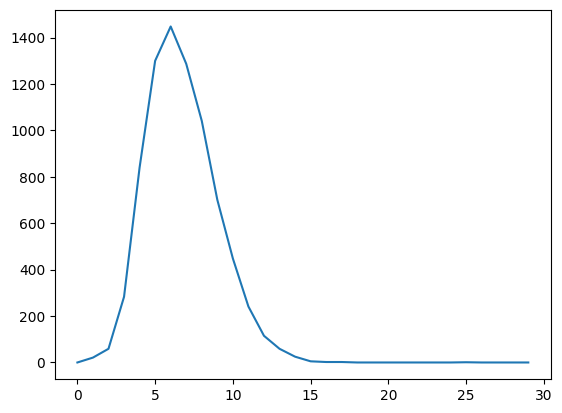

In [25]:
lens = [0 for i in range(30)]
for i in unq_words:
    lens[len(i)] +=1
plt.plot(lens)

In [35]:
counter = Counter(text.split())
counter
protect_words = []
for k,v in counter.items():
    if v >= 1000:
        protect_words.append(k)
    if len(protect_words) >= 1000:
        break
protect_words

Counter({'a': 31194,
         'the': 6276,
         'with': 6220,
         'on': 5802,
         'in': 5776,
         'of': 5758,
         'and': 5711,
         'is': 2718,
         'bathroom': 2438,
         'to': 2151,
         'an': 2036,
         'white': 1862,
         'sitting': 1717,
         'man': 1716,
         'toilet': 1706,
         'kitchen': 1497,
         'next': 1479,
         'two': 1259,
         'motorcycle': 1135,
         'people': 1073,
         'at': 1065,
         'parked': 1055,
         'small': 964,
         'are': 952,
         'large': 924,
         'woman': 909,
         'standing': 883,
         'sink': 870,
         'black': 781,
         'riding': 746,
         'that': 717,
         'street': 709,
         'has': 689,
         'cat': 684,
         'front': 675,
         'person': 621,
         'blue': 592,
         'plane': 581,
         'airplane': 567,
         'down': 559,
         'flying': 539,
         'up': 534,
         'top': 530,
         'by'

['a',
 'with',
 'the',
 'and',
 'white',
 'to',
 'parked',
 'is',
 'in',
 'bathroom',
 'on',
 'two',
 'an',
 'next',
 'kitchen',
 'man',
 'sitting',
 'of',
 'motorcycle',
 'toilet',
 'people',
 'at']

In [36]:
text[14215:14215+ 100]

'hroom with light flowing in the window. little girl in blue dress standing in a bathroom. a fighter '

In [ ]:
# vocab_size = 8192
# tokenizer = myTokenizer_faster(
#     token_model_file='./tokenizer/bpe8192.model',
#     special_tokens={
#         TOKEN_UNK : vocab_size - 5,
#         TOKEN_SOS : vocab_size - 4,
#         TOKEN_EOS : vocab_size - 3,
#         TOKEN_PAD : vocab_size - 2,
#         TOKEN_END : vocab_size - 1
#     } 
# )

# tokenizer._vocab_size() # default 256 with spl tokenms

In [3]:
from datasets.tokenizer import myTokenizer_faster

TOKEN_UNK = '<|unknown|>'
TOKEN_SOS = '<|startofseq|>'
TOKEN_EOS = '<|endofseq|>'
TOKEN_PAD = '<|padding|>'
TOKEN_END = '<|endoftext|>'

MAX_SEQ_LEN = 32

vocab_size = 8192
tokenizer = myTokenizer_faster(
    token_model_file=f"{tokenizer_models_dir}/bpe{vocab_size}.model",
    special_tokens={
        TOKEN_UNK : vocab_size - 5,
        TOKEN_SOS : vocab_size - 4,
        TOKEN_EOS : vocab_size - 3,
        TOKEN_PAD : vocab_size - 2,
        TOKEN_END : vocab_size - 1
    } 
)

tokenizer._vocab_size()
vocab_ = tokenizer.load()
tokenizer._vocab_size()

261

Loaded 7419 merges, 5 specials, 512 protected
Total vocabulary size: 8192


8192

In [4]:
dataset = COCODataset(
    train_folder, 
    train_ann_file, 
    tokenizer, 
    MAX_SEQ_LEN,
    default_stats='coco'
    )

In [5]:
dataloader = DataLoader(dataset, batch_size=16, shuffle=True, num_workers=4)

In [6]:
for images, captions in dataloader:
    print("Batch of images:", images.shape)
    print("Batch of captions:", captions.shape)
    break

Batch of images: torch.Size([16, 3, 224, 224])
Batch of captions: torch.Size([16, 32])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8619909..1.7656783].


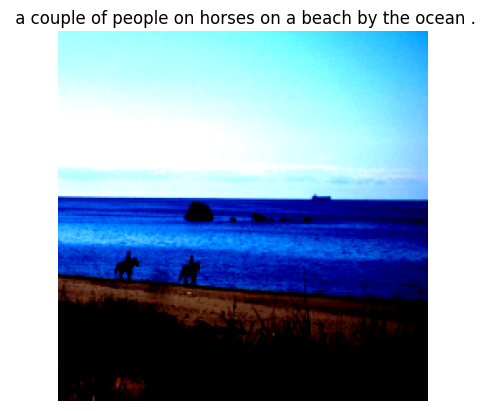

In [7]:
idx = 7
_ = plt.imshow(images[idx].permute(1,2,0))
_ = plt.title(tokenizer.decode(captions[idx].tolist()).replace(TOKEN_PAD, '').replace(TOKEN_SOS, '').replace(TOKEN_EOS, ''))
_ = plt.axis('off')